# Data Import & Basic Statistics

In [1]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
from pathlib import Path

RAW = Path('../data/archive/raw_20260528')

files = sorted(RAW.glob('ticks_*.parquet'))
df = pd.concat([pq.read_table(f).to_pandas() for f in files], ignore_index=True)
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df = df.sort_values('datetime').reset_index(drop=True)

print(f'Files loaded:    {len(files):,}')
print(f'Total ticks:     {len(df):,}')
print(f'Markets:         {df["market_id"].nunique():,}')
print(f'Time range:      {df["datetime"].min()}  →  {df["datetime"].max()}')
print(f'Duration:        {df["datetime"].max() - df["datetime"].min()}')
print()
print('--- Numeric summary ---')
display(df[['yes_price', 'no_price', 'btc_usd', 'btc_coinbase', 'btc_kraken']].describe().round(4))
print()
print('--- Missing values ---')
print(df.isnull().sum())
print()
print('--- Ticks per market (top 10) ---')
print(df.groupby('market_id').size().sort_values(ascending=False).head(10))

Files loaded:    407
Total ticks:     118,223
Markets:         404
Time range:      2026-05-26 09:53:08.731577+00:00  →  2026-05-27 20:45:00.277413+00:00
Duration:        1 days 10:51:51.545836

--- Numeric summary ---


,yes_price,no_price,btc_usd,btc_coinbase,btc_kraken
count,117598.0000,117598.0000,118210.0000,118217.0000,118214.0000
mean,0.5144,0.4945,75939.0703,75817.4531,75822.8594
std,0.3102,0.3102,667.0674,683.9205,681.8625
min,0.0010,0.0010,74669.9922,74534.4688,74548.2031
25%,0.2600,0.2400,75599.3516,75471.3594,75479.1016
50%,0.5200,0.4900,75887.7969,75765.8594,75770.4531
75%,0.7700,0.7500,76080.0078,75966.7188,75965.7031
max,1.0000,1.0000,78079.9922,78015.4609,77989.2969



--- Missing values ---
datetime          0
market_id         0
yes_price       625
no_price        625
btc_usd          13
btc_coinbase      6
btc_kraken        9
dtype: int64

--- Ticks per market (top 10) ---
market_id
0xd05bb4c749e18ced975d5f83c43ad1899f8d129fdd7855278701bfa21b84c672    298
0xda0f6524c82843bea1f33a11262d81596ef25e753be06d392d9799c0b4a59990    298
0xc06e1d0bd550d2ebc3b0a172185c3448f2ee5388362eafccecad26bb302077b2    298
0x252966881907e0872340e5575f5b29ab138c07a480c112642acda3effebb617c    297
0x26fd5b6d8800a23b19d51dc53274cdd1e364d933e3d27a56ea3227b51c9f353b    297
0xcd270277639fba3006b27b81107eea269c5e5399d2a58aa1c38c5d2e6cd8f0b5    297
0x9d0ee76298850828a16e2cccd63d23e4a34e8998eb0a6c23620dfdde4a8abbe5    297
0x2d9232b852168961dae8f6c600268ea32242b34a6cbde7ccf2ac24ef66916a12    297
0x666d2bfcb565c3d520844ad00f932aeb5fc9723decb228b2044d433f73f2920c    297
0xd0b4294a2bcd708335e41038f9bee26e66cae7c2b86aaf78371bc66e61f2f0b6    297
dtype: int64


## Missing Values

Missing per column:


,missing,pct
yes_price,625,0.53
no_price,625,0.53
btc_usd,13,0.01
btc_kraken,9,0.01
btc_coinbase,6,0.01


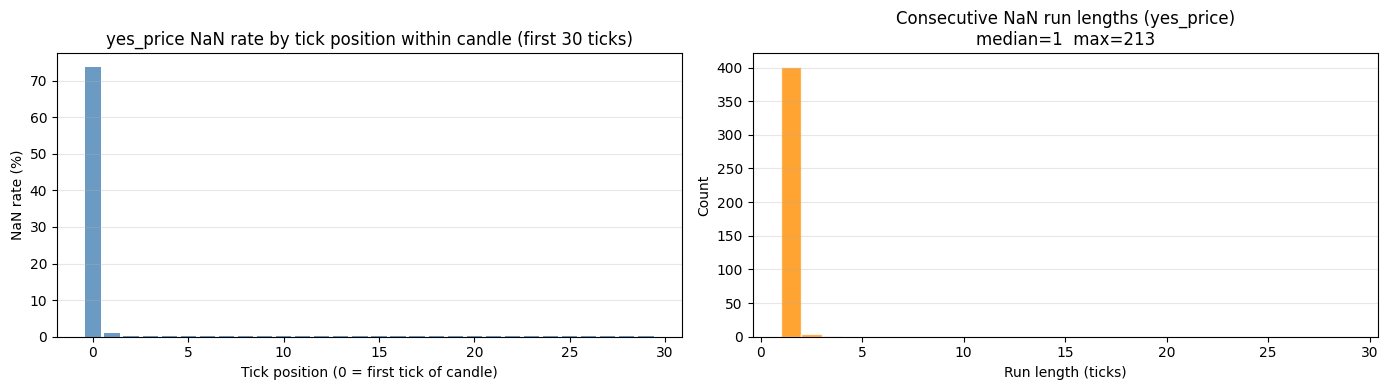


Markets with >20% NaN yes_price: 1

Top 10 markets by NaN rate:
market_id
0x3c7785508df8ad749b0b6540ca5940970c0ffbbe5c903631eb4b6d89a495d84a    100.0
0x726371aad65575908c997c58b5434fb08263fd6c4a08bf219ed0cd7037f7a30c      2.4
0x4160edbc94bad2477931dacd674540cc3a021253a12e64e796d30f0b91607a6a      1.4
0x03e6ee9f74edece2117ea408556a7d6d61ee7feb6775c5850c859980bc5ee9f2      0.9
0x5d88e37a4df630480fa02a29ce89cb500e6c16bb42fb653e2c571d7e9fb32be1      0.9
0xeae941900a436e489d66b8e9ca4d28c3996e3599b0b480ed24ea191ac1da6697      0.8
0x8a677b19a33eebfd6df0df12f0d4e1ecfadce5facc845ed8aaa3a0be8c51febe      0.8
0x406a95fbf9a15d360eef32ae0c394a463f45daa3fdd2d549def293fdb55d0053      0.7
0xfa48a4fe513800aada40b06ca1f298f88de19bc4bb2182ae20d99358a60ee573      0.7
0xea21f68e60cc4720cbb5fd88cde20c1da837873dc45c6e82d514032973bc4318      0.4


In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- Per-column summary ---
total = len(df)
missing = df.isnull().sum()
missing_df = pd.DataFrame({
    'missing': missing,
    'pct': (missing / total * 100).round(2),
}).sort_values('missing', ascending=False)
missing_df = missing_df[missing_df['missing'] > 0]
print('Missing per column:')
display(missing_df)

# --- Where in the candle do NaNs occur? (yes_price as proxy) ---
# Assign each tick a position within its candle
df['_candle'] = df['datetime'].dt.floor('5min')
df['_tick_pos'] = df.groupby(['market_id', '_candle']).cumcount()

nan_by_pos = df[df['yes_price'].isna()].groupby('_tick_pos').size()
all_by_pos = df.groupby('_tick_pos').size()
nan_rate_by_pos = (nan_by_pos / all_by_pos * 100).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(nan_rate_by_pos.index[:30], nan_rate_by_pos.values[:30], color='steelblue', alpha=0.8)
axes[0].set_title('yes_price NaN rate by tick position within candle (first 30 ticks)')
axes[0].set_xlabel('Tick position (0 = first tick of candle)')
axes[0].set_ylabel('NaN rate (%)')
axes[0].grid(True, alpha=0.3, axis='y')

# --- NaN runs: how many consecutive missing ticks per market? ---
run_lengths = []
for mid, grp in df.groupby('market_id'):
    is_nan = grp['yes_price'].isna().astype(int)
    # find run lengths
    run = (is_nan != is_nan.shift()).cumsum()
    runs = is_nan.groupby(run).agg(['sum', 'count'])
    runs = runs[runs['sum'] > 0]['count']  # only NaN runs
    run_lengths.extend(runs.tolist())

if run_lengths:
    rl = pd.Series(run_lengths)
    axes[1].hist(rl, bins=range(1, min(rl.max() + 2, 30)), color='darkorange', alpha=0.8, edgecolor='white')
    axes[1].set_title(f'Consecutive NaN run lengths (yes_price)\nmedian={rl.median():.0f}  max={rl.max()}')
    axes[1].set_xlabel('Run length (ticks)')
    axes[1].set_ylabel('Count')
    axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# --- Markets with highest NaN rate ---
nan_by_market = df.groupby('market_id')['yes_price'].apply(lambda x: x.isna().mean() * 100).sort_values(ascending=False)
print(f'\nMarkets with >20% NaN yes_price: {(nan_by_market > 20).sum()}')
print('\nTop 10 markets by NaN rate:')
print(nan_by_market.head(10).round(1).to_string())

# Cleanup
df.drop(columns=['_candle', '_tick_pos'], inplace=True)

## Feature Engineering

In [3]:
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed

_BINANCE_URL  = "https://api.binance.com/api/v3/klines"
_COINBASE_URL = "https://api.exchange.coinbase.com/products/BTC-USD/candles"
_KRAKEN_URL   = "https://api.kraken.com/0/public/OHLC"

def _fetch_binance_open(candle_ts):
    try:
        r = requests.get(_BINANCE_URL,
                         params={"symbol": "BTCUSDT", "interval": "5m",
                                 "startTime": candle_ts * 1000, "limit": 1},
                         timeout=10)
        d = r.json()
        return float(d[0][1]) if d else None
    except Exception:
        return None

def _fetch_coinbase_open(candle_ts):
    try:
        start = pd.Timestamp(candle_ts, unit='s', tz='UTC').isoformat()
        end   = pd.Timestamp(candle_ts + 300, unit='s', tz='UTC').isoformat()
        r = requests.get(_COINBASE_URL,
                         params={"granularity": 300, "start": start, "end": end},
                         timeout=10)
        for c in r.json():
            if int(c[0]) == candle_ts:
                return float(c[3])
    except Exception:
        return None
    return None

def _fetch_kraken_open(candle_ts):
    try:
        r = requests.get(_KRAKEN_URL,
                         params={"pair": "XBTUSD", "interval": 5, "since": candle_ts - 1},
                         timeout=10)
        data = r.json()
        result = data.get("result", {})
        candles = result.get("XXBTZUSD", result.get("XBTZUSD", []))
        for c in candles:
            if int(c[0]) == candle_ts:
                return float(c[1])
    except Exception:
        return None
    return None

def _fetch_all(candle_ts):
    return candle_ts, _fetch_binance_open(candle_ts), _fetch_coinbase_open(candle_ts), _fetch_kraken_open(candle_ts)

candle_tss = sorted({int(t.timestamp()) for t in df['datetime'].dt.floor('5min')})
print(f'Fetching open prices for {len(candle_tss)} candles...')

open_prices = {}  # {candle_ts: (binance, coinbase, kraken)}
with ThreadPoolExecutor(max_workers=8) as ex:
    futures = {ex.submit(_fetch_all, ts): ts for ts in candle_tss}
    for i, fut in enumerate(as_completed(futures), 1):
        ts, b, c, k = fut.result()
        open_prices[ts] = (b, c, k)
        if i % 50 == 0 or i == len(candle_tss):
            print(f'  {i}/{len(candle_tss)}')

missing = {ex: sum(1 for v in open_prices.values() if v[i] is None)
           for i, ex in enumerate(['binance', 'coinbase', 'kraken'])}
print(f'\nMissing opens — {missing}')

Fetching open prices for 406 candles...
  50/406
  100/406
  150/406
  200/406
  250/406
  300/406
  350/406
  400/406
  406/406

Missing opens — {'binance': 0, 'coinbase': 71, 'kraken': 391}


In [4]:
CANDLE_SECONDS = 300

feat = df.copy()
feat['candle_ts']    = feat['datetime'].dt.floor('5min').apply(lambda t: int(t.timestamp()))
feat['elapsed_s']    = (feat['datetime'] - feat['datetime'].dt.floor('5min')).dt.total_seconds()
feat['time_remaining'] = (CANDLE_SECONDS - feat['elapsed_s']).clip(lower=0).astype(int)
feat['spread'] = feat['yes_price'] + feat['no_price'] - 1.0

for i, (raw_col, feat_col) in enumerate([
    ('btc_usd',      'pct_change_binance'),
    ('btc_coinbase', 'pct_change_coinbase'),
    ('btc_kraken',   'pct_change_kraken'),
]):
    open_px = feat['candle_ts'].map(lambda ts, i=i: open_prices.get(ts, (None, None, None))[i])
    feat[feat_col] = (feat[raw_col] - open_px) / open_px

features = feat[[
    'datetime', 'market_id',
    'yes_price', 'no_price', 'time_remaining',
    'pct_change_binance', 'pct_change_coinbase', 'pct_change_kraken',
    'spread'
]]

print(f'NaN values in features: {features.isna().sum()}')
print()
display(features.describe().round(6))

NaN values in features: datetime                    0
market_id                   0
yes_price                 625
no_price                  625
time_remaining              0
pct_change_binance         13
pct_change_coinbase     20832
pct_change_kraken      113972
spread                    625
dtype: int64



,yes_price,no_price,time_remaining,pct_change_binance,pct_change_coinbase,pct_change_kraken,spread
count,117598.000000,117598.000000,118223.000000,118210.000000,97391.000000,4251.000000,117598.000000
mean,0.514401,0.494511,148.651658,-0.000013,-0.000015,0.000078,0.008912
std,0.310246,0.310190,86.214194,0.000811,0.000845,0.001026,0.007532
min,0.001000,0.001000,0.000000,-0.008367,-0.008522,-0.003682,-0.140000
25%,0.260000,0.240000,74.000000,-0.000335,-0.000317,-0.000334,0.010000
50%,0.520000,0.490000,149.000000,0.000000,0.000012,0.000035,0.010000
75%,0.770000,0.750000,223.000000,0.000357,0.000355,0.000481,0.010000
max,1.000000,1.000000,299.000000,0.006247,0.006412,0.003838,0.380000


In [5]:
features = features[
    ['datetime', 'market_id', 'yes_price', 'no_price', 'spread',
     'time_remaining','pct_change_binance']
].dropna().reset_index(drop=True)

print(f'Rows before dropna: {len(feat):,}')
print(f'Rows after dropna:  {len(features):,}  ({100*(1 - len(features)/len(feat)):.1f}% dropped)')
print(f'Markets:            {features["market_id"].nunique():,}')

Rows before dropna: 118,223
Rows after dropna:  117,594  (0.5% dropped)
Markets:            403


## Statistics by Time-Remaining Bucket

Bucket size: 10s  |  30 buckets


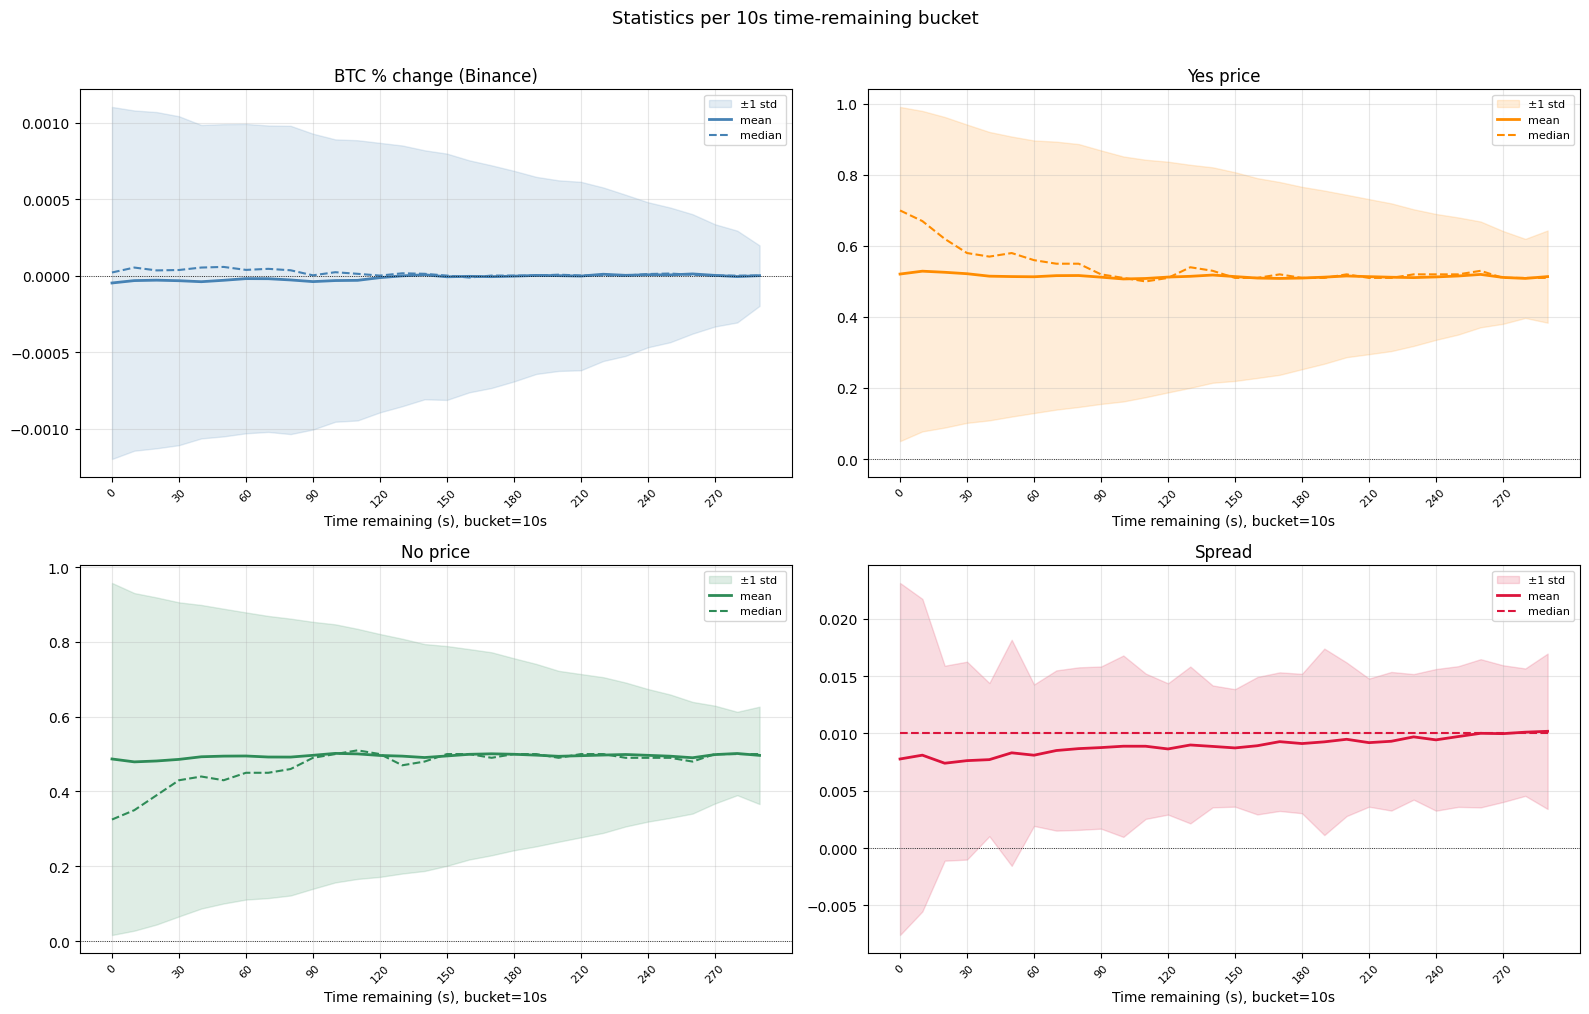

In [6]:
import matplotlib.pyplot as plt

BUCKET_SECONDS = 10  # ← change this

features['spread'] = features['yes_price'] + features['no_price'] - 1.0

bins = range(0, 301, BUCKET_SECONDS)
features['time_bucket'] = pd.cut(features['time_remaining'], bins=list(bins), right=False)

metrics = ['pct_change_binance', 'yes_price', 'no_price', 'spread']
stats = (
    features.groupby('time_bucket', observed=True)[metrics]
    .agg(['mean', 'std', 'median', 'min', 'max'])
)
print(f'Bucket size: {BUCKET_SECONDS}s  |  {len(stats)} buckets')
# display(stats.round(6))

# --- Plots ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
labels = [str(b.left) for b in stats.index]
x = range(len(stats))

colors = {'pct_change_binance': 'steelblue', 'yes_price': 'darkorange',
          'no_price': 'seagreen', 'spread': 'crimson'}
titles = {'pct_change_binance': 'BTC % change (Binance)',
          'yes_price': 'Yes price', 'no_price': 'No price', 'spread': 'Spread'}

for ax, metric in zip(axes, metrics):
    col   = colors[metric]
    mean  = stats[metric]['mean']
    std   = stats[metric]['std']
    med   = stats[metric]['median']

    ax.fill_between(x, mean - std, mean + std, color=col, alpha=0.15, label='±1 std')
    ax.plot(x, mean,   color=col,   linewidth=2,   label='mean')
    ax.plot(x, med,    color=col,   linewidth=1.5, linestyle='--', label='median')
    ax.axhline(0, color='black', linewidth=0.6, linestyle=':')

    step = max(1, len(x) // 10)
    ax.set_xticks(x[::step])
    ax.set_xticklabels(labels[::step], rotation=45, fontsize=8)
    ax.set_xlabel(f'Time remaining (s), bucket={BUCKET_SECONDS}s')
    ax.set_title(titles[metric])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Statistics per {BUCKET_SECONDS}s time-remaining bucket', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Red vs Green Candles (Binance)

Total candles:  403
Green:           205  (50.9%)
Red:             198  (49.1%)
Doji (flat):       0  (0.0%)



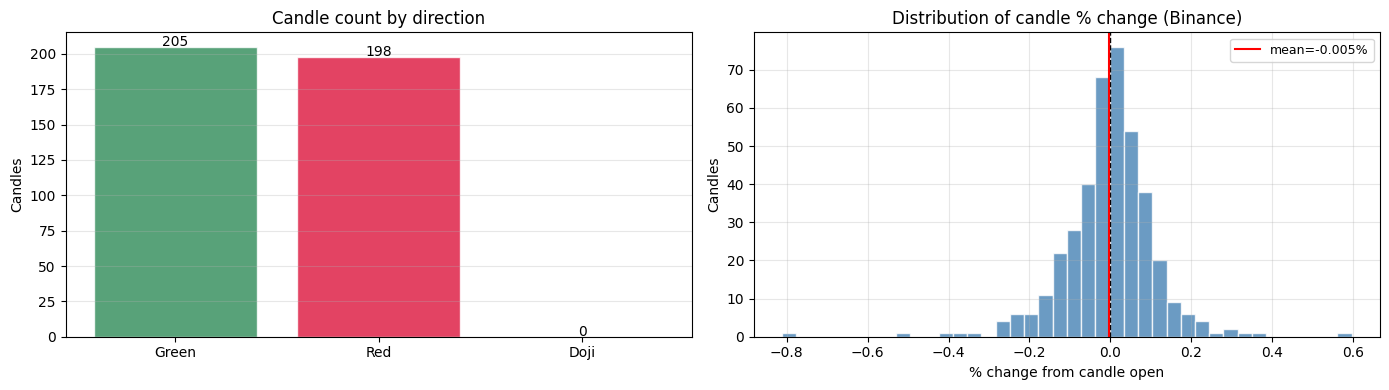

In [7]:
# Last tick per candle = smallest time_remaining per (market_id)
candle_close = (
    features.sort_values('time_remaining')
    .groupby('market_id')
    .first()  # first after sort by time_remaining = closest to close
    .reset_index()
)

candle_close['color'] = np.where(
    candle_close['pct_change_binance'] > 0, 'green',
    np.where(candle_close['pct_change_binance'] < 0, 'red', 'doji')
)

counts = candle_close['color'].value_counts()
total  = len(candle_close)

print(f'Total candles:  {total}')
print(f'Green:          {counts.get("green", 0):4d}  ({100*counts.get("green", 0)/total:.1f}%)')
print(f'Red:            {counts.get("red",   0):4d}  ({100*counts.get("red",   0)/total:.1f}%)')
print(f'Doji (flat):    {counts.get("doji",  0):4d}  ({100*counts.get("doji",  0)/total:.1f}%)')
print()

# Distribution of final pct_change
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(['Green', 'Red', 'Doji'],
            [counts.get('green', 0), counts.get('red', 0), counts.get('doji', 0)],
            color=['seagreen', 'crimson', 'gray'], alpha=0.8, edgecolor='white')
axes[0].set_title('Candle count by direction')
axes[0].set_ylabel('Candles')
for i, (label, cnt) in enumerate(zip(['Green', 'Red', 'Doji'],
                                      [counts.get('green', 0), counts.get('red', 0), counts.get('doji', 0)])):
    axes[0].text(i, cnt + 0.3, str(cnt), ha='center', fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].hist(candle_close['pct_change_binance'] * 100,
             bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1, linestyle='--')
axes[1].axvline(candle_close['pct_change_binance'].mean() * 100,
                color='red', linewidth=1.5, label=f'mean={candle_close["pct_change_binance"].mean()*100:+.3f}%')
axes[1].set_title('Distribution of candle % change (Binance)')
axes[1].set_xlabel('% change from candle open')
axes[1].set_ylabel('Candles')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## BTC 5m Candles — SMA/EMA & Directional Stats

Fetching 5m candles from 2026-05-26 09:53:08.731577+00:00 → 2026-05-27 20:45:00.277413+00:00
Fetched 419 candles

Candles: 419  |  2026-05-26 09:55:00+00:00 → 2026-05-27 20:45:00+00:00


/var/folders/q7/0s4jjvb94hb_2_90j2545plw0000gn/T/ipykernel_3489/1106704569.py:49: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(candles[['open_time','open','high','low','close','sma9','sma20','ema9','ema20']].tail(5).round(2))


,open_time,open,high,low,close,sma9,sma20,ema9,ema20
414,2026-05-27 20:25:00+00:00,75300.57,75330.42,75273.96,75282.00,75203.93,75109.63,75229.88,75141.25
415,2026-05-27 20:30:00+00:00,75282.01,75294.63,75214.00,75238.46,75233.62,75122.38,75231.60,75150.51
416,2026-05-27 20:35:00+00:00,75238.45,75275.58,75238.45,75242.61,75254.19,75133.18,75233.80,75159.28
417,2026-05-27 20:40:00+00:00,75242.62,75254.01,75231.21,75252.00,75274.84,75143.18,75237.44,75168.11
418,2026-05-27 20:45:00+00:00,75252.01,75290.23,75252.00,75290.22,75287.84,75157.09,75247.99,75179.74



--- Directional stats ---


,n,green,red,green_pct,red_pct,mean_chg,median_chg,std_chg
label,,,,,,,,
SMA9 — open above,194,95,99,49.0,51.0,-0.0083,-0.0012,0.1154
SMA9 — open below,216,111,105,51.4,48.6,-0.0053,0.0049,0.1115
SMA20 — open above,181,88,93,48.6,51.4,-0.0071,-0.0013,0.1112
SMA20 — open below,218,113,105,51.8,48.2,-0.0057,0.0062,0.1164
EMA9 — open above,207,102,105,49.3,50.7,-0.0050,-0.0012,0.1175
EMA9 — open below,211,111,100,52.6,47.4,-0.0036,0.0076,0.1124
EMA20 — open above,193,92,101,47.7,52.3,-0.0068,-0.0020,0.1165
EMA20 — open below,225,121,104,53.8,46.2,-0.0021,0.0085,0.1136


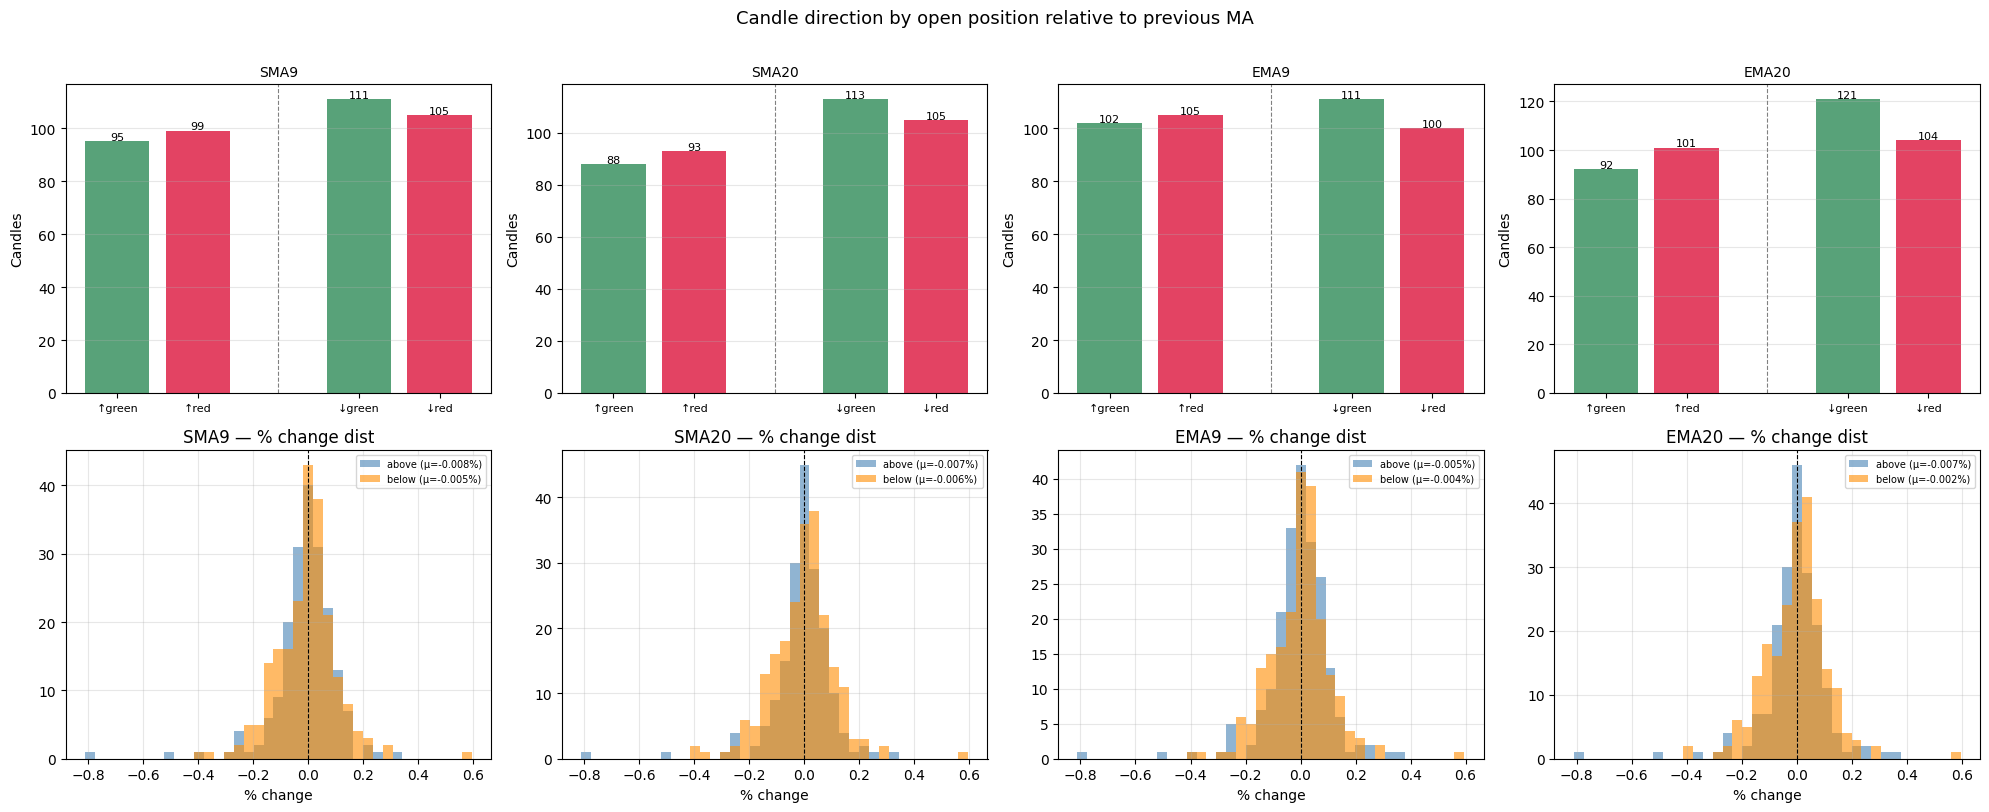

In [8]:
import requests

_KLINES_URL = "https://api.binance.com/api/v3/klines"

def fetch_klines(start_ms: int, end_ms: int) -> list:
    rows = []
    since = start_ms
    while since < end_ms:
        r = requests.get(_KLINES_URL, params={
            "symbol": "BTCUSDT", "interval": "5m",
            "startTime": since, "endTime": end_ms, "limit": 1000,
        }, timeout=15)
        batch = r.json()
        if not batch:
            break
        rows.extend(batch)
        since = batch[-1][0] + 1  # next ms after last candle open
        if len(batch) < 1000:
            break
    return rows

start_ms = int(df['datetime'].min().timestamp() * 1000)
end_ms   = int(df['datetime'].max().timestamp() * 1000)

print(f'Fetching 5m candles from {df["datetime"].min()} → {df["datetime"].max()}')
raw_klines = fetch_klines(start_ms, end_ms)
print(f'Fetched {len(raw_klines)} candles')

candles = pd.DataFrame(raw_klines, columns=[
    'open_time','open','high','low','close','volume',
    'close_time','quote_volume','n_trades',
    'taker_buy_base','taker_buy_quote','ignore'
])
candles['open_time'] = pd.to_datetime(candles['open_time'], unit='ms', utc=True)
for col in ['open', 'high', 'low', 'close']:
    candles[col] = candles[col].astype(float)
candles = candles.sort_values('open_time').reset_index(drop=True)

# SMA & EMA
for n in [9, 20]:
    candles[f'sma{n}'] = candles['close'].rolling(n).mean()
    candles[f'ema{n}'] = candles['close'].ewm(span=n, adjust=False).mean()

candles['pct_change'] = (candles['close'] - candles['open']) / candles['open'] * 100
candles['direction']  = np.where(candles['pct_change'] > 0, 'green',
                         np.where(candles['pct_change'] < 0, 'red', 'doji'))

print(f'\nCandles: {len(candles)}  |  {candles["open_time"].min()} → {candles["open_time"].max()}')
display(candles[['open_time','open','high','low','close','sma9','sma20','ema9','ema20']].tail(5).round(2))

# --- Stats: open above / below previous candle's MA ---
def candle_stats(mask, label):
    sub = candles[mask]
    if len(sub) == 0:
        print(f'{label}: no data')
        return None
    green = (sub['direction'] == 'green').sum()
    red   = (sub['direction'] == 'red').sum()
    return {
        'label':      label,
        'n':          len(sub),
        'green':      green,
        'red':        red,
        'green_pct':  round(100 * green / len(sub), 1),
        'red_pct':    round(100 * red   / len(sub), 1),
        'mean_chg':   round(sub['pct_change'].mean(), 4),
        'median_chg': round(sub['pct_change'].median(), 4),
        'std_chg':    round(sub['pct_change'].std(), 4),
    }

rows = []
for ma in ['sma9', 'sma20', 'ema9', 'ema20']:
    prev_ma = candles[ma].shift(1)
    above = candles['open'] > prev_ma
    below = candles['open'] < prev_ma
    valid = prev_ma.notna()
    rows.append(candle_stats(valid & above, f'{ma.upper()} — open above'))
    rows.append(candle_stats(valid & below, f'{ma.upper()} — open below'))

stats_df = pd.DataFrame([r for r in rows if r]).set_index('label')
print('\n--- Directional stats ---')
display(stats_df)

# --- Plot ---
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for row, ma in enumerate(['sma9', 'sma20', 'ema9', 'ema20']):
    prev_ma = candles[ma].shift(1)
    valid   = prev_ma.notna()
    above   = candles[valid & (candles['open'] > prev_ma)]['pct_change']
    below   = candles[valid & (candles['open'] < prev_ma)]['pct_change']

    # Bar chart: green/red counts
    ax_bar  = axes[0][row]
    ax_hist = axes[1][row]

    ab_g = (above > 0).sum(); ab_r = (above < 0).sum()
    bl_g = (below > 0).sum(); bl_r = (below < 0).sum()
    x = [0, 1, 3, 4]
    ax_bar.bar(x, [ab_g, ab_r, bl_g, bl_r],
               color=['seagreen', 'crimson', 'seagreen', 'crimson'], alpha=0.8)
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(['↑green', '↑red', '↓green', '↓red'], fontsize=8)
    ax_bar.set_title(f'{ma.upper()}', fontsize=10)
    ax_bar.set_ylabel('Candles')
    for xi, yi in zip(x, [ab_g, ab_r, bl_g, bl_r]):
        ax_bar.text(xi, yi + 0.5, str(yi), ha='center', fontsize=8)
    ax_bar.axvline(2, color='gray', linewidth=0.8, linestyle='--')
    ax_bar.grid(True, alpha=0.3, axis='y')

    # Histogram: pct_change distribution above vs below
    lo = min(above.min(), below.min())
    hi = max(above.max(), below.max())
    bins = np.linspace(lo, hi, 40)
    ax_hist.hist(above, bins=bins, color='steelblue', alpha=0.6, label=f'above (μ={above.mean():+.3f}%)')
    ax_hist.hist(below, bins=bins, color='darkorange', alpha=0.6, label=f'below (μ={below.mean():+.3f}%)')
    ax_hist.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax_hist.set_title(f'{ma.upper()} — % change dist')
    ax_hist.set_xlabel('% change')
    ax_hist.legend(fontsize=7)
    ax_hist.grid(True, alpha=0.3)

plt.suptitle('Candle direction by open position relative to previous MA', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## EMA 9 / 20 / 34 — All Combinations

--- Combination stats ---


,n,green,red,green_pct,red_pct,mean_chg
combo,,,,,,
9↑ 20↑ 34↑,139,58,81,41.7,58.3,-0.0134
9↑ 20↑ 34↓,33,21,12,63.6,36.4,0.0194
9↑ 20↓ 34↑,4,3,1,75.0,25.0,0.0004
9↑ 20↓ 34↓,31,20,11,64.5,35.5,0.0064
9↓ 20↑ 34↑,16,9,7,56.2,43.8,-0.0169
9↓ 20↑ 34↓,5,4,1,80.0,20.0,0.0371
9↓ 20↓ 34↑,5,4,1,80.0,20.0,0.0398
9↓ 20↓ 34↓,185,94,91,50.8,49.2,-0.0047


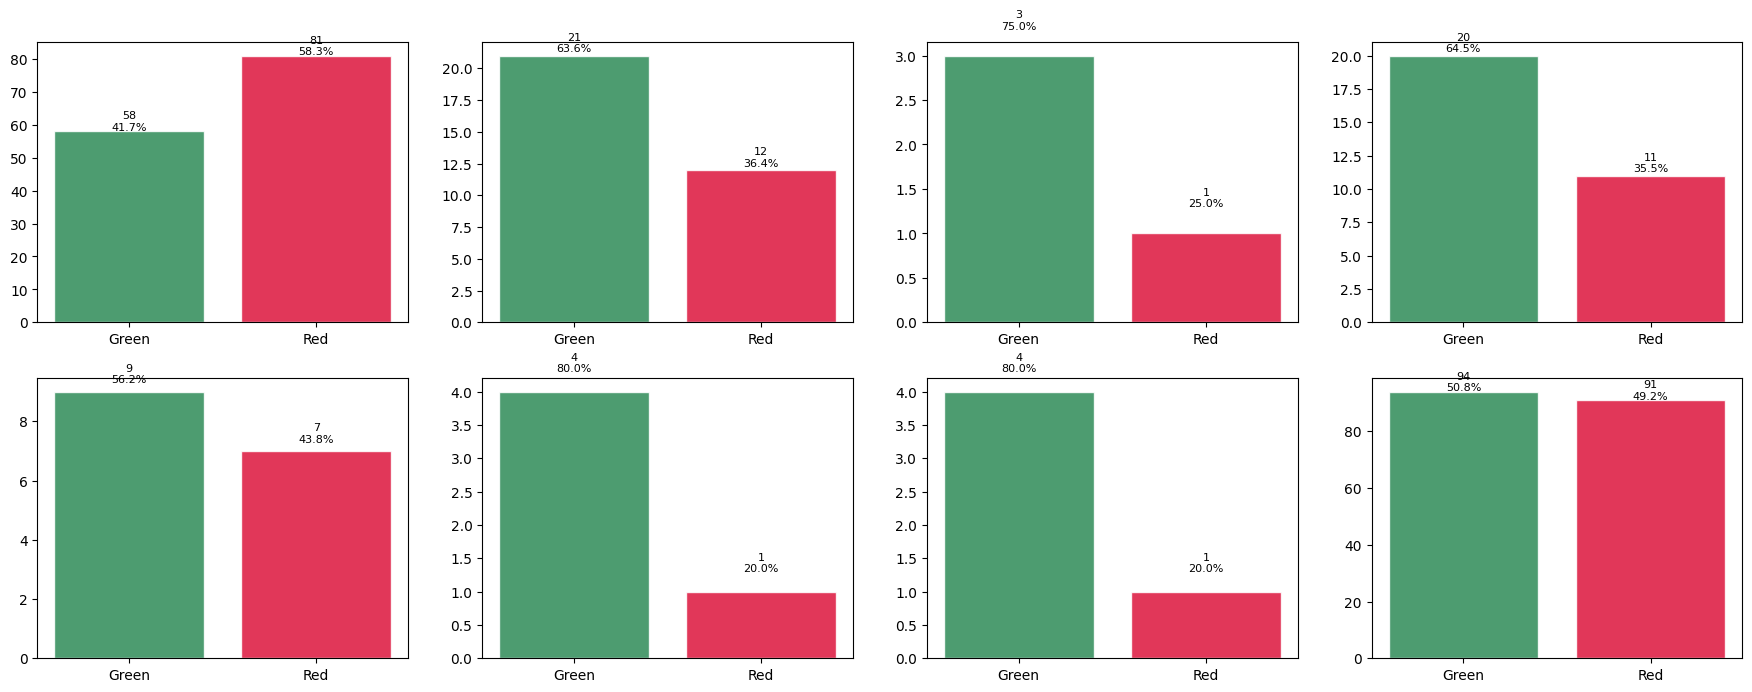

In [9]:
# Add EMA34 (9 and 20 already computed above)
candles['ema34'] = candles['close'].ewm(span=34, adjust=False).mean()

# Previous candle's EMA values
prev = {n: candles[f'ema{n}'].shift(1) for n in [9, 20, 34]}
valid = prev[9].notna() & prev[20].notna() & prev[34].notna()

# Build combination masks
combos = []
for s9 in [('above', True), ('below', False)]:
    for s20 in [('above', True), ('below', False)]:
        for s34 in [('above', True), ('below', False)]:
            label = f'9{("↑" if s9[1] else "↓")} 20{("↑" if s20[1] else "↓")} 34{("↑" if s34[1] else "↓")}'
            mask = valid
            mask = mask & (candles['open'] > prev[9]  if s9[1]  else candles['open'] <= prev[9])
            mask = mask & (candles['open'] > prev[20] if s20[1] else candles['open'] <= prev[20])
            mask = mask & (candles['open'] > prev[34] if s34[1] else candles['open'] <= prev[34])
            combos.append((label, mask))

# Summary table
rows = []
for label, mask in combos:
    sub = candles[mask]
    n     = len(sub)
    green = (sub['direction'] == 'green').sum()
    red   = (sub['direction'] == 'red').sum()
    rows.append({
        'combo':      label,
        'n':          n,
        'green':      green,
        'red':        red,
        'green_pct':  round(100 * green / n, 1) if n else 0,
        'red_pct':    round(100 * red   / n, 1) if n else 0,
        'mean_chg':   round(sub['pct_change'].mean(), 4) if n else 0,
    })

stats_df = pd.DataFrame(rows).set_index('combo')
print('--- Combination stats ---')
display(stats_df)

# --- Bar charts ---
n_combos = len(combos)
fig, axes = plt.subplots(2, n_combos // 2, figsize=(22, 8))
axes = axes.flatten()

for ax, (label, mask), row in zip(axes, combos, rows):
    n     = row['n']
    green = row['green']
    red   = row['red']

    bars = ax.bar(['Green', 'Red'], [green, red],
                  color=['seagreen', 'crimson'], alpha=0.85, edgecolor='white')
    ax.text(0, green + 0.3, f'{green}\n{row["green_pct"]}%', ha='center', fontsize=8)
    ax.text(1, red   + 0.3, f'{red}\n{row["red_pct"]}%',   ha='center', fontsize=8)


Fetching 5m candles from 2017-08-17 → now
  50,000 candles fetched...
  100,000 candles fetched...
  150,000 candles fetched...
  200,000 candles fetched...
  250,000 candles fetched...
  300,000 candles fetched...
  350,000 candles fetched...
  400,000 candles fetched...
  450,000 candles fetched...
  500,000 candles fetched...
  550,000 candles fetched...
  600,000 candles fetched...
  650,000 candles fetched...
  700,000 candles fetched...
  750,000 candles fetched...
  800,000 candles fetched...
  850,000 candles fetched...
  900,000 candles fetched...
Fetched 921,675 candles

Candles: 921,675  |  2017-08-17 04:00:00+00:00 → 2026-05-28 09:05:00+00:00


/var/folders/q7/0s4jjvb94hb_2_90j2545plw0000gn/T/ipykernel_3489/2498630490.py:53: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(candles[['open_time','open','high','low','close','sma9','sma20','ema9','ema20']].tail(5).round(2))


,open_time,open,high,low,close,sma9,sma20,ema9,ema20
921670,2026-05-28 08:45:00+00:00,73292.92,73376.84,73290.42,73332.01,73341.38,73358.91,73328.03,73312.40
921671,2026-05-28 08:50:00+00:00,73332.00,73353.28,73332.00,73342.28,73332.25,73365.36,73330.88,73315.24
921672,2026-05-28 08:55:00+00:00,73342.28,73342.94,73306.65,73325.88,73318.57,73367.15,73329.88,73316.26
921673,2026-05-28 09:00:00+00:00,73325.88,73388.01,73311.62,73365.99,73310.48,73369.87,73337.10,73320.99
921674,2026-05-28 09:05:00+00:00,73365.99,73398.64,73333.00,73334.88,73313.24,73373.66,73336.66,73322.32



--- Directional stats ---


,n,green,red,green_pct,red_pct,mean_chg,median_chg,std_chg
label,,,,,,,,
SMA9 — open above,468799,222446,243735,47.5,52.0,-0.0017,-0.0046,0.2251
SMA9 — open below,452820,237163,213332,52.4,47.1,0.0027,0.0056,0.2504
SMA20 — open above,472614,225229,244692,47.7,51.8,-0.0012,-0.0040,0.2216
SMA20 — open below,449034,234379,212372,52.2,47.3,0.0022,0.0053,0.2539
EMA9 — open above,471616,223029,245920,47.3,52.1,-0.0022,-0.0051,0.2238
EMA9 — open below,450055,236588,211154,52.6,46.9,0.0033,0.0062,0.2518
EMA20 — open above,475440,226038,246674,47.5,51.9,-0.0017,-0.0043,0.2201
EMA20 — open below,446231,233579,210400,52.3,47.2,0.0027,0.0057,0.2555


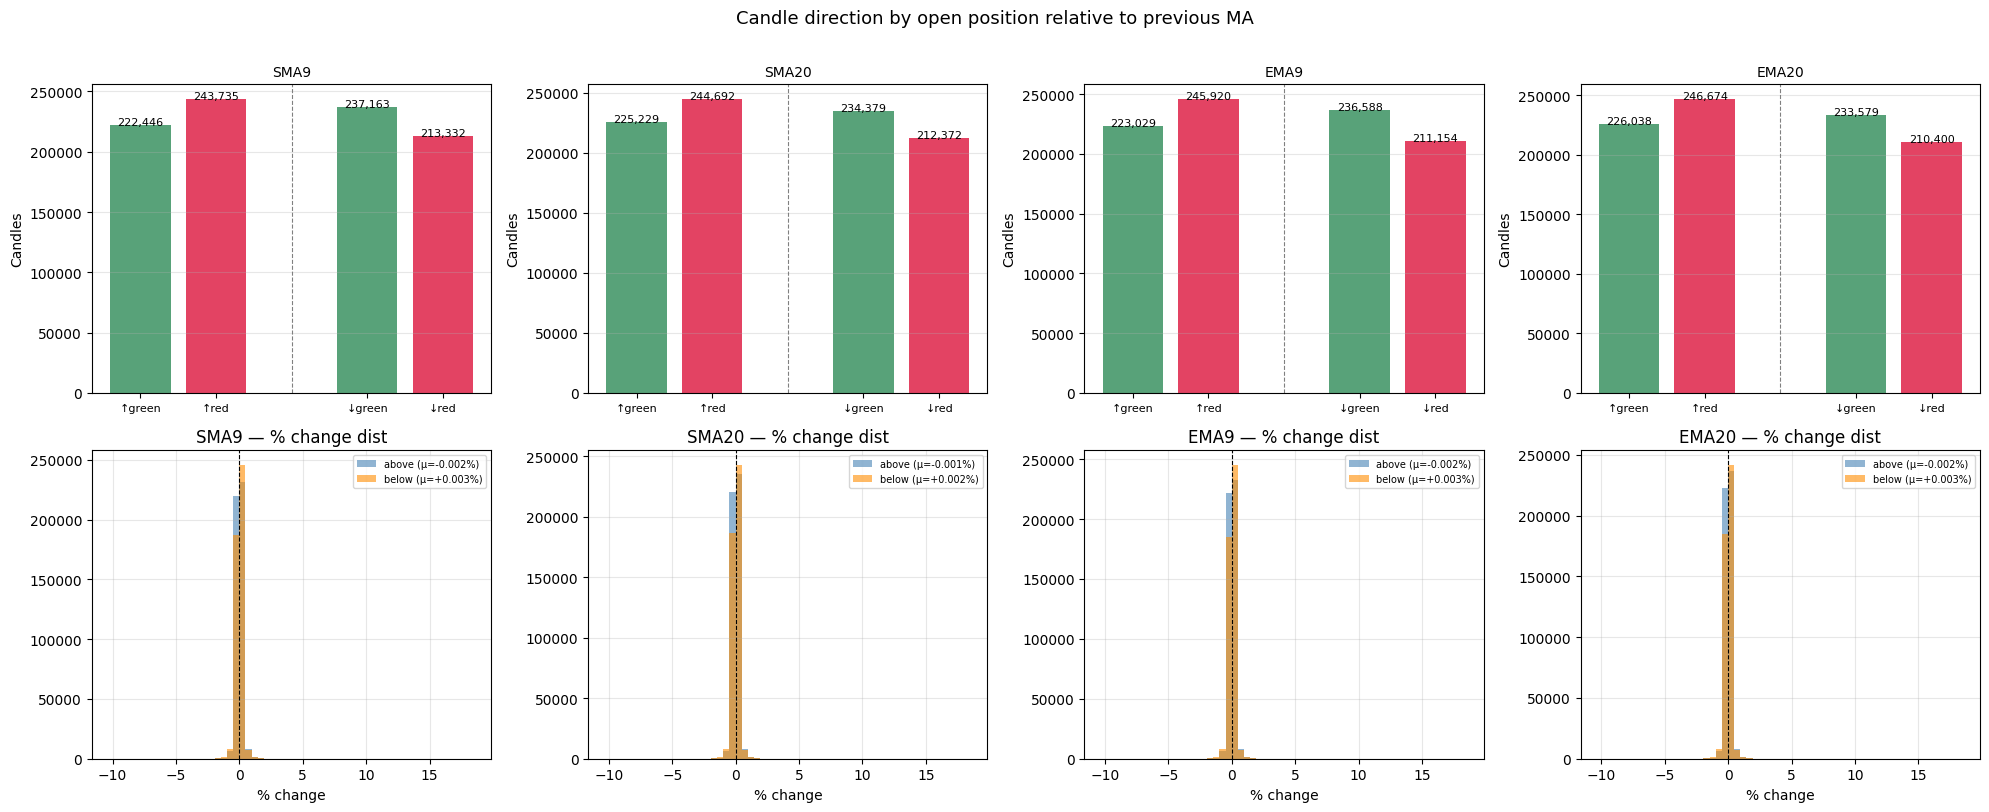

In [10]:
import requests
from datetime import datetime, timezone

_KLINES_URL = "https://api.binance.com/api/v3/klines"

START_DATE = '2017-08-17'  # ← earliest BTCUSDT 5m data on Binance; change as needed

def fetch_klines(start_ms: int, end_ms: int) -> list:
    rows = []
    since = start_ms
    while since < end_ms:
        r = requests.get(_KLINES_URL, params={
            "symbol": "BTCUSDT", "interval": "5m",
            "startTime": since, "endTime": end_ms, "limit": 1000,
        }, timeout=15)
        batch = r.json()
        if not batch:
            break
        rows.extend(batch)
        since = batch[-1][0] + 1
        if len(batch) < 1000:
            break
        if len(rows) % 50000 == 0:
            print(f'  {len(rows):,} candles fetched...')
    return rows

start_ms = int(datetime.fromisoformat(START_DATE).replace(tzinfo=timezone.utc).timestamp() * 1000)
end_ms   = int(datetime.now(tz=timezone.utc).timestamp() * 1000)

print(f'Fetching 5m candles from {START_DATE} → now')
raw_klines = fetch_klines(start_ms, end_ms)
print(f'Fetched {len(raw_klines):,} candles')

candles = pd.DataFrame(raw_klines, columns=[
    'open_time','open','high','low','close','volume',
    'close_time','quote_volume','n_trades',
    'taker_buy_base','taker_buy_quote','ignore'
])
candles['open_time'] = pd.to_datetime(candles['open_time'], unit='ms', utc=True)
for col in ['open', 'high', 'low', 'close']:
    candles[col] = candles[col].astype(float)
candles = candles.sort_values('open_time').reset_index(drop=True)

for n in [9, 20]:
    candles[f'sma{n}'] = candles['close'].rolling(n).mean()
    candles[f'ema{n}'] = candles['close'].ewm(span=n, adjust=False).mean()

candles['pct_change'] = (candles['close'] - candles['open']) / candles['open'] * 100
candles['direction']  = np.where(candles['pct_change'] > 0, 'green',
                         np.where(candles['pct_change'] < 0, 'red', 'doji'))

print(f'\nCandles: {len(candles):,}  |  {candles["open_time"].min()} → {candles["open_time"].max()}')
display(candles[['open_time','open','high','low','close','sma9','sma20','ema9','ema20']].tail(5).round(2))

def candle_stats(mask, label):
    sub = candles[mask]
    if len(sub) == 0:
        return None
    green = (sub['direction'] == 'green').sum()
    red   = (sub['direction'] == 'red').sum()
    return {
        'label':      label,
        'n':          len(sub),
        'green':      green,
        'red':        red,
        'green_pct':  round(100 * green / len(sub), 1),
        'red_pct':    round(100 * red   / len(sub), 1),
        'mean_chg':   round(sub['pct_change'].mean(), 4),
        'median_chg': round(sub['pct_change'].median(), 4),
        'std_chg':    round(sub['pct_change'].std(), 4),
    }

rows = []
for ma in ['sma9', 'sma20', 'ema9', 'ema20']:
    prev_ma = candles[ma].shift(1)
    valid   = prev_ma.notna()
    rows.append(candle_stats(valid & (candles['open'] > prev_ma), f'{ma.upper()} — open above'))
    rows.append(candle_stats(valid & (candles['open'] < prev_ma), f'{ma.upper()} — open below'))

stats_df = pd.DataFrame([r for r in rows if r]).set_index('label')
print('\n--- Directional stats ---')
display(stats_df)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for col_idx, ma in enumerate(['sma9', 'sma20', 'ema9', 'ema20']):
    prev_ma = candles[ma].shift(1)
    valid   = prev_ma.notna()
    above   = candles[valid & (candles['open'] > prev_ma)]['pct_change']
    below   = candles[valid & (candles['open'] < prev_ma)]['pct_change']

    ax_bar  = axes[0][col_idx]
    ax_hist = axes[1][col_idx]

    ab_g = (above > 0).sum(); ab_r = (above < 0).sum()
    bl_g = (below > 0).sum(); bl_r = (below < 0).sum()
    x = [0, 1, 3, 4]
    ax_bar.bar(x, [ab_g, ab_r, bl_g, bl_r],
               color=['seagreen', 'crimson', 'seagreen', 'crimson'], alpha=0.8)
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(['↑green', '↑red', '↓green', '↓red'], fontsize=8)
    ax_bar.set_title(f'{ma.upper()}', fontsize=10)
    ax_bar.set_ylabel('Candles')
    for xi, yi in zip(x, [ab_g, ab_r, bl_g, bl_r]):
        ax_bar.text(xi, yi + 0.5, f'{yi:,}', ha='center', fontsize=8)
    ax_bar.axvline(2, color='gray', linewidth=0.8, linestyle='--')
    ax_bar.grid(True, alpha=0.3, axis='y')

    lo = min(above.min(), below.min()); hi = max(above.max(), below.max())
    bins = np.linspace(lo, hi, 60)
    ax_hist.hist(above, bins=bins, color='steelblue', alpha=0.6, label=f'above (μ={above.mean():+.3f}%)')
    ax_hist.hist(below, bins=bins, color='darkorange', alpha=0.6, label=f'below (μ={below.mean():+.3f}%)')
    ax_hist.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax_hist.set_title(f'{ma.upper()} — % change dist')
    ax_hist.set_xlabel('% change')
    ax_hist.legend(fontsize=7)
    ax_hist.grid(True, alpha=0.3)

plt.suptitle('Candle direction by open position relative to previous MA', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


--- Combination stats ---


,n,green,red,green_pct,red_pct,mean_chg
combo,,,,,,
9↑ 20↑ 34↑,373351,174851,196342,46.8,52.6,-0.0024
9↑ 20↑ 34↓,38506,18744,19516,48.7,50.7,-0.0011
9↑ 20↓ 34↑,2811,1412,1387,50.2,49.3,0.0021
9↑ 20↓ 34↓,56948,28022,28675,49.2,50.4,-0.0018
9↓ 20↑ 34↑,60941,31146,29479,51.1,48.4,0.0026
9↓ 20↑ 34↓,2642,1297,1337,49.1,50.6,-0.0019
9↓ 20↓ 34↑,40895,20979,19662,51.3,48.1,0.0015
9↓ 20↓ 34↓,345580,183166,160676,53.0,46.5,0.0037


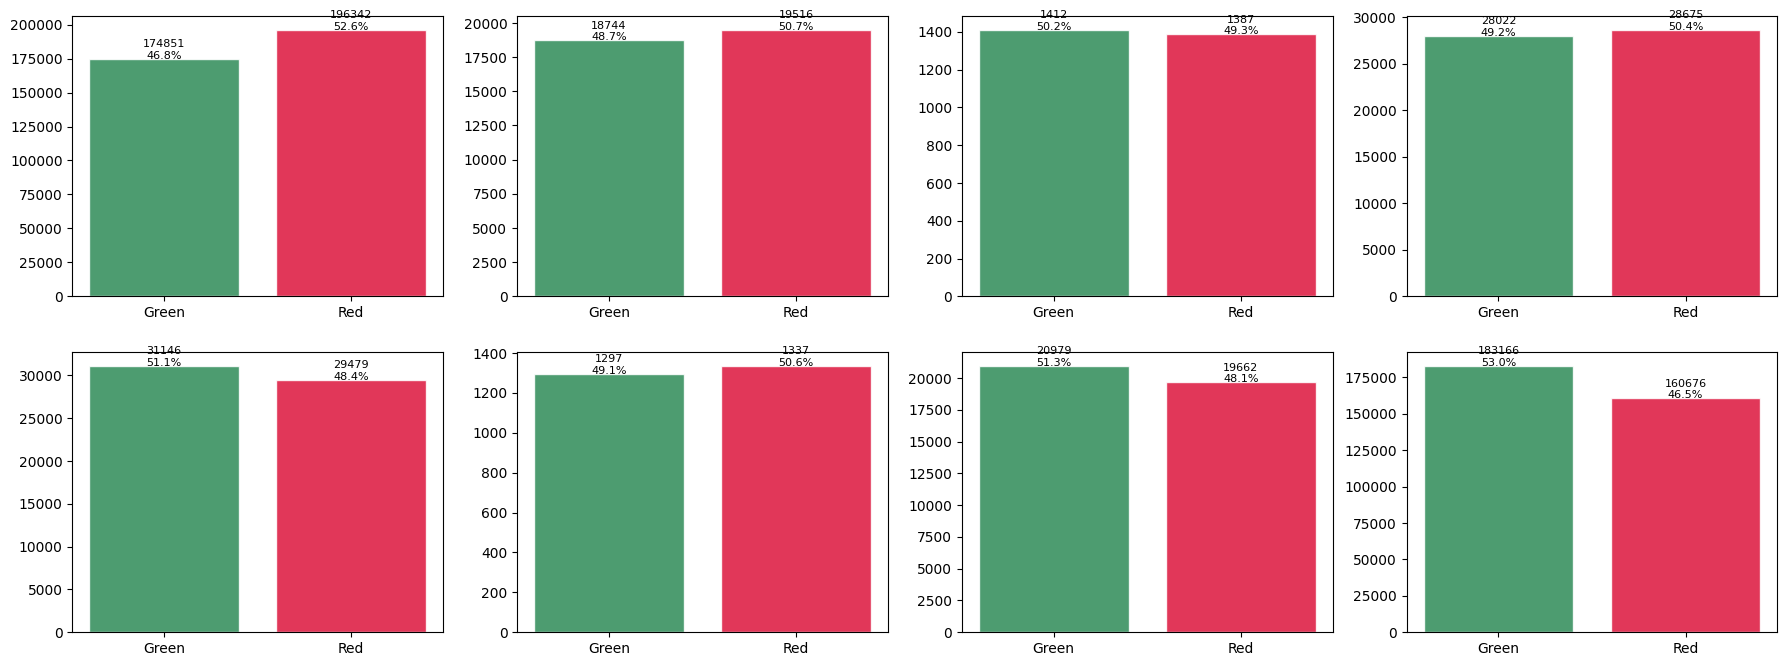

In [11]:
# Add EMA34 (9 and 20 already computed above)
candles['ema34'] = candles['close'].ewm(span=34, adjust=False).mean()

# Previous candle's EMA values
prev = {n: candles[f'ema{n}'].shift(1) for n in [9, 20, 34]}
valid = prev[9].notna() & prev[20].notna() & prev[34].notna()

# Build combination masks
combos = []
for s9 in [('above', True), ('below', False)]:
    for s20 in [('above', True), ('below', False)]:
        for s34 in [('above', True), ('below', False)]:
            label = f'9{("↑" if s9[1] else "↓")} 20{("↑" if s20[1] else "↓")} 34{("↑" if s34[1] else "↓")}'
            mask = valid
            mask = mask & (candles['open'] > prev[9]  if s9[1]  else candles['open'] <= prev[9])
            mask = mask & (candles['open'] > prev[20] if s20[1] else candles['open'] <= prev[20])
            mask = mask & (candles['open'] > prev[34] if s34[1] else candles['open'] <= prev[34])
            combos.append((label, mask))

# Summary table
rows = []
for label, mask in combos:
    sub = candles[mask]
    n     = len(sub)
    green = (sub['direction'] == 'green').sum()
    red   = (sub['direction'] == 'red').sum()
    rows.append({
        'combo':      label,
        'n':          n,
        'green':      green,
        'red':        red,
        'green_pct':  round(100 * green / n, 1) if n else 0,
        'red_pct':    round(100 * red   / n, 1) if n else 0,
        'mean_chg':   round(sub['pct_change'].mean(), 4) if n else 0,
    })

stats_df = pd.DataFrame(rows).set_index('combo')
print('--- Combination stats ---')
display(stats_df)

# --- Bar charts ---
n_combos = len(combos)
fig, axes = plt.subplots(2, n_combos // 2, figsize=(22, 8))
axes = axes.flatten()

for ax, (label, mask), row in zip(axes, combos, rows):
    n     = row['n']
    green = row['green']
    red   = row['red']

    bars = ax.bar(['Green', 'Red'], [green, red],
                  color=['seagreen', 'crimson'], alpha=0.85, edgecolor='white')
    ax.text(0, green + 0.3, f'{green}\n{row["green_pct"]}%', ha='center', fontsize=8)
    ax.text(1, red   + 0.3, f'{red}\n{row["red_pct"]}%',   ha='center', fontsize=8)


## Yes / No Prices in First 20 Seconds

Markets: 397  |  Total ticks in first 20s: 7,940



,yes_mean,yes_std,yes_median,no_mean,spread_mean,spread_std,n_valid,availability_pct
tick,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0000
1,0.5096,0.0629,0.51,0.5013,0.0109,0.0066,393,98.9924
2,0.5088,0.0744,0.51,0.5014,0.0102,0.0042,396,99.7481
3,0.5088,0.0798,0.51,0.5016,0.0104,0.0070,396,99.7481
4,0.5094,0.0850,0.51,0.5011,0.0105,0.0070,396,99.7481
5,0.5083,0.0885,0.51,0.5017,0.0099,0.0047,396,99.7481
6,0.5106,0.0945,0.51,0.5002,0.0108,0.0101,396,99.7481
7,0.5110,0.0993,0.51,0.4994,0.0104,0.0064,396,99.7481
8,0.5107,0.1038,0.51,0.4995,0.0102,0.0053,396,99.7481


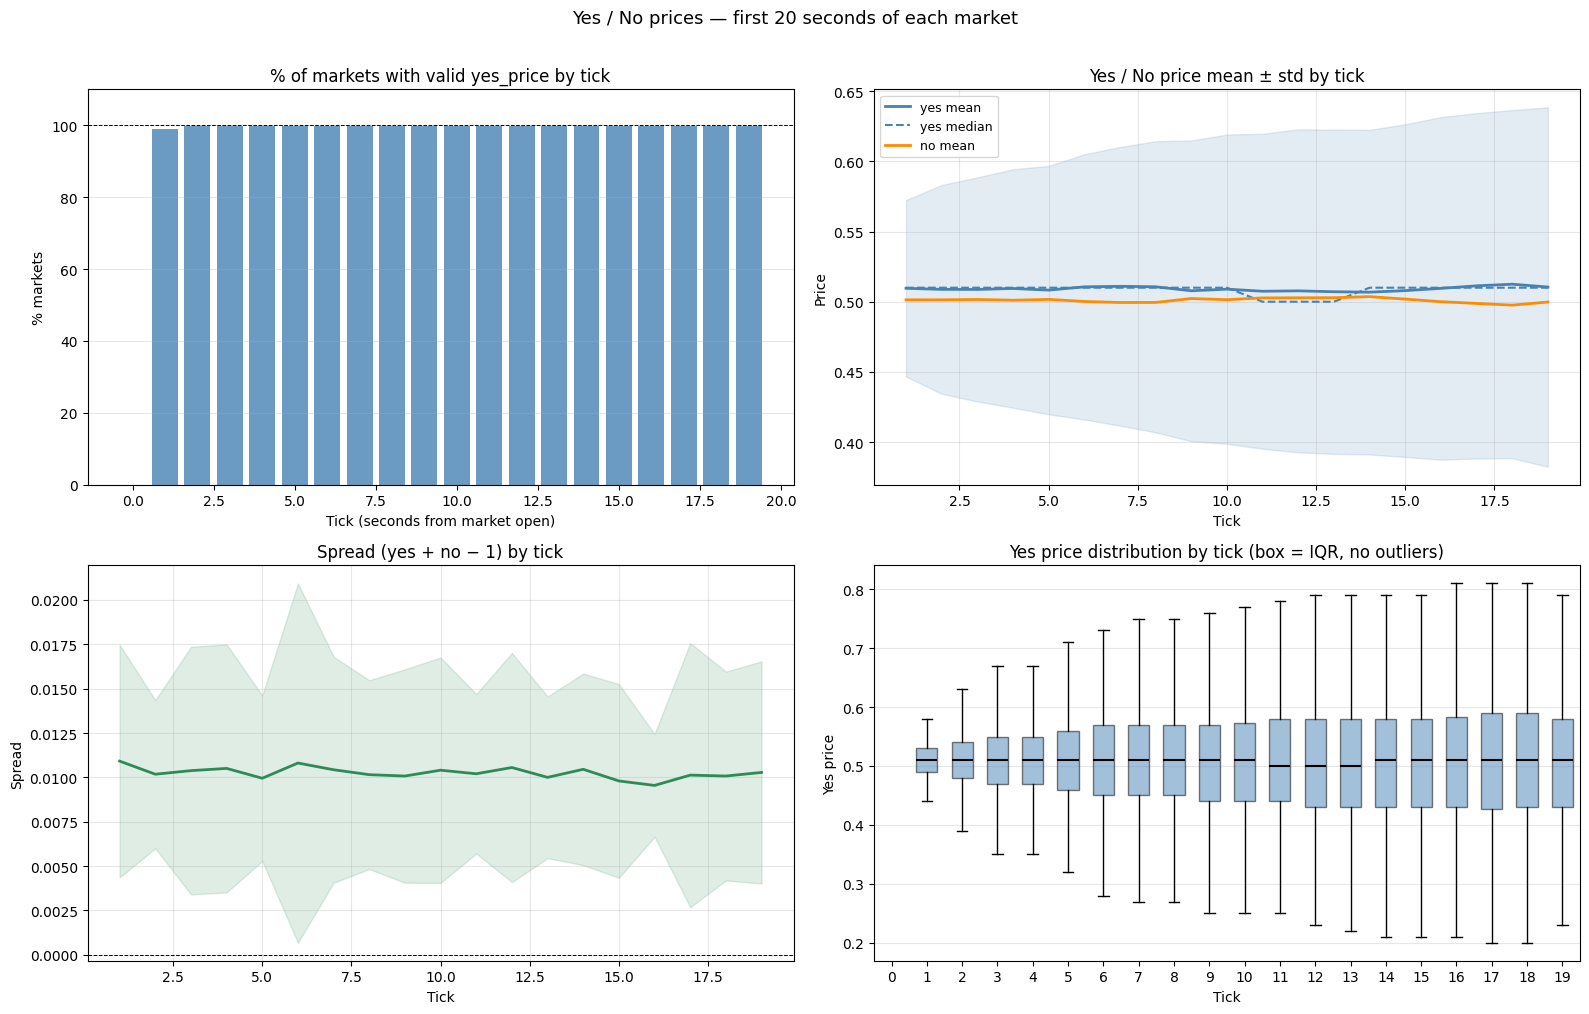

In [26]:
# Use raw df to capture NaNs (prices not yet available)
first20 = (
    df.sort_values('datetime')
    .groupby('market_id')
    .head(20)
    .copy()
)
first20['tick'] = first20.groupby('market_id').cumcount()
first20['spread'] = first20['yes_price'] + first20['no_price'] - 1.0

# --- 1. Data availability: how many markets have valid yes_price at each tick ---
availability = (
    first20.groupby('tick')['yes_price']
    .apply(lambda x: x.notna().sum())
    .rename('markets_with_price')
)
total_markets = first20['market_id'].nunique()

# --- 2. Per-tick stats (exclude NaN) ---
tick_stats = first20.groupby('tick').agg(
    yes_mean=('yes_price', 'mean'),
    yes_std=('yes_price', 'std'),
    yes_median=('yes_price', 'median'),
    no_mean=('no_price', 'mean'),
    spread_mean=('spread', 'mean'),
    spread_std=('spread', 'std'),
    n_valid=('yes_price', 'count'),
)
tick_stats['availability_pct'] = tick_stats['n_valid'] / total_markets * 100

print(f'Markets: {total_markets}  |  Total ticks in first 20s: {len(first20):,}')
print()
display(tick_stats.round(4))

# --- Plots ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ticks = tick_stats.index

# Top-left: availability
axes[0][0].bar(ticks, tick_stats['availability_pct'], color='steelblue', alpha=0.8)
axes[0][0].axhline(100, color='black', linewidth=0.7, linestyle='--')
axes[0][0].set_title('% of markets with valid yes_price by tick')
axes[0][0].set_xlabel('Tick (seconds from market open)')
axes[0][0].set_ylabel('% markets')
axes[0][0].set_ylim(0, 110)
axes[0][0].grid(True, alpha=0.3, axis='y')

# Top-right: mean yes/no price ± std
axes[0][1].fill_between(ticks,
    tick_stats['yes_mean'] - tick_stats['yes_std'],
    tick_stats['yes_mean'] + tick_stats['yes_std'],
    color='steelblue', alpha=0.15)
axes[0][1].plot(ticks, tick_stats['yes_mean'],   color='steelblue',  linewidth=2, label='yes mean')
axes[0][1].plot(ticks, tick_stats['yes_median'], color='steelblue',  linewidth=1.5, linestyle='--', label='yes median')
axes[0][1].plot(ticks, tick_stats['no_mean'],    color='darkorange', linewidth=2, label='no mean')
axes[0][1].set_title('Yes / No price mean ± std by tick')
axes[0][1].set_xlabel('Tick')
axes[0][1].set_ylabel('Price')
axes[0][1].legend(fontsize=9)
axes[0][1].grid(True, alpha=0.3)

# Bottom-left: spread mean ± std
axes[1][0].fill_between(ticks,
    tick_stats['spread_mean'] - tick_stats['spread_std'],
    tick_stats['spread_mean'] + tick_stats['spread_std'],
    color='seagreen', alpha=0.15)
axes[1][0].plot(ticks, tick_stats['spread_mean'], color='seagreen', linewidth=2)
axes[1][0].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[1][0].set_title('Spread (yes + no − 1) by tick')
axes[1][0].set_xlabel('Tick')
axes[1][0].set_ylabel('Spread')
axes[1][0].grid(True, alpha=0.3)

# Bottom-right: box plot of yes_price at each tick
valid_by_tick = [first20[first20['tick'] == t]['yes_price'].dropna().values for t in range(20)]
bp = axes[1][1].boxplot(valid_by_tick, positions=range(20), widths=0.6,
                         patch_artist=True, showfliers=False,
                         boxprops=dict(facecolor='steelblue', alpha=0.5),
                         medianprops=dict(color='black', linewidth=1.5))
axes[1][1].set_title('Yes price distribution by tick (box = IQR, no outliers)')
axes[1][1].set_xlabel('Tick')
axes[1][1].set_ylabel('Yes price')
axes[1][1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Yes / No prices — first 20 seconds of each market', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [12]:
# ── Yes Price & Resolution by BTC % Change Bucket ────────────────────────────
BUCKET_SIZE = 0.001   # 0.1% buckets

df_snap = features.copy()

bucket_edges = np.arange(
    np.floor(df_snap["pct_change_binance"].min() / BUCKET_SIZE) * BUCKET_SIZE,
    np.ceil(df_snap["pct_change_binance"].max() / BUCKET_SIZE) * BUCKET_SIZE + BUCKET_SIZE,
    BUCKET_SIZE,
)
df_snap["pct_bucket"] = pd.cut(
    df_snap["pct_change_binance"], bins=bucket_edges, right=False
)

grouped = (
    df_snap.groupby("pct_bucket", observed=True)
    .agg(
        mean_yes_price=("yes_price", "mean"),
        resolution_rate=("resolved_yes", "mean"),
        count=("yes_price", "count"),
    )
    .dropna()
)
grouped["bucket_mid"] = grouped.index.map(lambda i: i.mid)
grouped = grouped[grouped["count"] >= 30]   # drop sparse buckets

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f"BTC % Change Buckets (size={BUCKET_SIZE*100:.2f}%)", fontsize=13)

x = np.arange(len(grouped))
labels = [f"{v*100:.1f}%" for v in grouped["bucket_mid"]]

axes[0].bar(x, grouped["resolution_rate"], color="steelblue", width=0.8)
axes[0].axhline(0.5, color="red", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("Resolution rate (YES)")
axes[0].set_ylim(0, 1)

axes[1].bar(x, grouped["mean_yes_price"], color="darkorange", width=0.8)
axes[1].axhline(0.5, color="red", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("Mean yes_price")
axes[1].set_ylim(0, 1)

axes[2].bar(x, grouped["resolution_rate"] - grouped["mean_yes_price"],
            color=["green" if v > 0 else "red"
                   for v in grouped["resolution_rate"] - grouped["mean_yes_price"]],
            width=0.8)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_ylabel("Edge (resolution − yes_price)")

step = max(1, len(x) // 20)
for ax in axes:
    ax.set_xticks(x[::step])
    ax.set_xticklabels(labels[::step], rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nBucket summary ({len(grouped)} buckets with ≥30 rows):")
print(grouped[["count", "mean_yes_price", "resolution_rate", "bucket_mid"]]
      .sort_values("bucket_mid")
      .to_string())


KeyError: "Label(s) ['resolved_yes'] do not exist"

In [13]:
features

,datetime,market_id,yes_price,no_price,spread,time_remaining,pct_change_binance,time_bucket
0,2026-05-26 09:53:10.748349+00:00,0x5d88e37a4df630480fa02a29ce89cb500e6c16bb42fb...,0.82,0.19,0.01,109,2.973533e-04,"[100, 110)"
1,2026-05-26 09:53:11.758688+00:00,0x5d88e37a4df630480fa02a29ce89cb500e6c16bb42fb...,0.82,0.19,0.01,108,2.973533e-04,"[100, 110)"
2,2026-05-26 09:53:12.763842+00:00,0x5d88e37a4df630480fa02a29ce89cb500e6c16bb42fb...,0.83,0.18,0.01,107,2.973533e-04,"[100, 110)"
3,2026-05-26 09:53:13.776104+00:00,0x5d88e37a4df630480fa02a29ce89cb500e6c16bb42fb...,0.76,0.25,0.01,106,2.416008e-04,"[100, 110)"
4,2026-05-26 09:53:14.789150+00:00,0x5d88e37a4df630480fa02a29ce89cb500e6c16bb42fb...,0.76,0.25,0.01,105,2.416008e-04,"[100, 110)"
...,...,...,...,...,...,...,...,...
117589,2026-05-27 20:44:56.236543+00:00,0x0aee2a59ee4a63b537955649baf296ef4b55e261d1e2...,1.00,0.01,0.01,3,1.247672e-04,"[0, 10)"
117590,2026-05-27 20:44:57.242534+00:00,0x0aee2a59ee4a63b537955649baf296ef4b55e261d1e2...,0.99,0.01,0.00,2,1.247672e-04,"[0, 10)"
117591,2026-05-27 20:44:58.252027+00:00,0x0aee2a59ee4a63b537955649baf296ef4b55e261d1e2...,0.99,0.01,0.00,1,1.246634e-04,"[0, 10)"
117592,2026-05-27 20:44:59.261130+00:00,0x0aee2a59ee4a63b537955649baf296ef4b55e261d1e2...,0.99,0.01,0.00,0,1.246634e-04,"[0, 10)"
